<a href="https://www.kaggle.com/code/saibhossain/dcgan-architecture-ipynb?scriptVersionId=288654761" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Dataset 

This dataset contain only 512 celebrity faces. thats so samall may not effective for face generation. we only focuse on the architecture here.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/7e9a220301bc25efdcde814015f222e2.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/f7ee2474535b92973e393a8bb8a34b20.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/a0968550fb151519fd5cf3232e006765.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/b92b4c8c4eaa22c70312432f1a2bf615.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/ad4e1a7c30b48f8bf6598aa22c8db20b.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/9f037204c099bd3ffbb85973fb9bef5e.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/4671731b43b497d14e33211935866aaf.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/f1fecd64ac79a85c236f28b3c84e6bf2.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces/Johnny depp/bf1c4e89c2496843d9df7380b7c8835c.jpg
/kaggle/input/celebrity-face-small-data/Celebrity faces

## ata augmentations

Generate 6,144 image form 512 image dataset 

In [2]:
import os
import random
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as transforms

# --- CONFIGURATION ---
INPUT_DIR = "/kaggle/input/celebrity-face-small-data"  
OUTPUT_DIR = "/kaggle/working/Augmented_Dataset" 
MULTIPLIER = 12  # How many new images to create per original image

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define the augmentations
# We use a randomized pipeline to ensure every generated image is slightly different
augmentor = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Rotate +/- 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shift image slightly
    # Optional: Add Gaussian Blur or Noise if you have it defined
])

def augment_and_save():
    print(f"Reading from: {INPUT_DIR}")
    print(f"Target size: {MULTIPLIER}x original count")

    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp')
    files = []

    # Recursively find images
    for root, _, filenames in os.walk(INPUT_DIR):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                files.append(os.path.join(root, filename))

    print(f"Found {len(files)} original images.")

    count = 0
    for file_path in tqdm(files):
        try:
            img = Image.open(file_path).convert("RGB")

            # Save the original first
            original_name = f"orig_{count}.png"
            img.save(os.path.join(OUTPUT_DIR, original_name))

            # Generate variations
            for i in range(MULTIPLIER):
                aug_img = augmentor(img)
                aug_name = f"aug_{count}_{i}.png"
                aug_img.save(os.path.join(OUTPUT_DIR, aug_name))

            count += 1
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    print(f"\n Done! Dataset expanded to {len(os.listdir(OUTPUT_DIR))} images.")
    print(f"Saved in: {OUTPUT_DIR}")

if __name__ == "__main__":
    augment_and_save()

Reading from: /kaggle/input/celebrity-face-small-data
Target size: 12x original count
Found 512 original images.


100%|██████████| 512/512 [12:41<00:00,  1.49s/it]


 Done! Dataset expanded to 6656 images.
Saved in: /kaggle/working/Augmented_Dataset


# DCGAN

In [3]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATAROOT = "/kaggle/working/Augmented_Dataset"
WORKERS = 2
BATCH_SIZE = 128
IMAGE_SIZE = 64
NC = 3
NZ = 100
NGF = 64
NDF = 64
NUM_EPOCHS = 150  # DCGAN use > 50 epochs < 250 epochs
LR = 0.0002
BETA1 = 0.5
NGPU = 1
OUT_DIR = "./dcgan_results"

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
# --- CUSTOM DATA LOADER (Handles flat folder structure) ---
class FlatFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.files = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        from PIL import Image
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, 0
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE), 0

def get_dataloader():
    dataset = FlatFolderDataset(
        root=DATAROOT,
        transform=transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
    )
    return torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS)

# --- MODELS ---
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print("DATA LOADER Ready")

DATA LOADER Ready


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Z -> 4x4
            nn.ConvTranspose2d(NZ, NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8),
            nn.ReLU(True),
            # 4x4 -> 8x8
            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

print("Generator Ready")

Generator Ready


In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32 -> 16x16
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16 -> 8x8
            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 8x8 -> 4x4
            nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4 -> 1x1
            nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

print("Discriminator Ready")

Discriminator Ready


In [7]:
# ---------------- TRAINING ----------------
def train():
    print("Starting DCGAN Training")

    dataloader = get_dataloader()

    netG = Generator().to(device)
    netD = Discriminator().to(device)

    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.BCELoss()
    fixed_noise = torch.randn(64, NZ, 1, 1, device=device)

    optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

    best_g_loss = float("inf")
    BEST_G_PATH = os.path.join(OUT_DIR, "best_generator.pth")
    BEST_D_PATH = os.path.join(OUT_DIR, "best_discriminator.pth")

    for epoch in range(NUM_EPOCHS):
        for i, (data, _) in enumerate(dataloader):

            # ---- Train Discriminator ----
            netD.zero_grad()
            real = data.to(device)
            b_size = real.size(0)
            label = torch.full((b_size,), 1., device=device)

            output = netD(real).view(-1)
            errD_real = criterion(output, label)
            errD_real.backward()

            noise = torch.randn(b_size, NZ, 1, 1, device=device)
            fake = netG(noise)
            label.fill_(0.)

            output = netD(fake.detach()).view(-1)
            errD_fake = criterion(output, label)
            errD_fake.backward()

            optimizerD.step()

            # ---- Train Generator ----
            netG.zero_grad()
            label.fill_(1.)
            output = netD(fake).view(-1)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()

            # ---- Save BEST model ----
            if errG.item() < best_g_loss:
                best_g_loss = errG.item()

                torch.save({
                    "epoch": epoch,
                    "generator_state_dict": netG.state_dict(),
                    "optimizerG_state_dict": optimizerG.state_dict(),
                    "g_loss": best_g_loss
                }, BEST_G_PATH)

                torch.save({
                    "epoch": epoch,
                    "discriminator_state_dict": netD.state_dict(),
                    "optimizerD_state_dict": optimizerD.state_dict(),
                    "d_loss": (errD_real + errD_fake).item()
                }, BEST_D_PATH)

                print(f"Best model saved | Epoch {epoch} | G Loss {best_g_loss:.4f}")

            if i % 50 == 0:
                print(
                    f"[{epoch}/{NUM_EPOCHS}] "
                    f"[{i}/{len(dataloader)}] "
                    f"Loss_D: {(errD_real+errD_fake).item():.4f} "
                    f"Loss_G: {errG.item():.4f}"
                )

        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
        vutils.save_image(
            fake,
            f"{OUT_DIR}/epoch_{epoch}.png",
            normalize=True
        )

    print("DCGAN Training Finished")


print("Are you Ready to Train your first GAN Model !")

Are you Ready to Train your first GAN Model !


In [8]:
train()

Starting DCGAN Training
Best model saved | Epoch 0 | G Loss 5.2402
[0/150] [0/52] Loss_D: 2.0287 Loss_G: 5.2402
[0/150] [50/52] Loss_D: 0.5852 Loss_G: 14.3872
[1/150] [0/52] Loss_D: 2.2884 Loss_G: 23.2906
Best model saved | Epoch 1 | G Loss 4.7535
Best model saved | Epoch 1 | G Loss 3.9437
Best model saved | Epoch 1 | G Loss 3.7466
Best model saved | Epoch 1 | G Loss 3.5054
Best model saved | Epoch 1 | G Loss 3.2884
[1/150] [50/52] Loss_D: 0.5991 Loss_G: 7.8612
[2/150] [0/52] Loss_D: 0.3366 Loss_G: 5.2931
Best model saved | Epoch 2 | G Loss 3.2548
Best model saved | Epoch 2 | G Loss 2.9877
Best model saved | Epoch 2 | G Loss 1.8859
[2/150] [50/52] Loss_D: 1.2200 Loss_G: 12.5082
[3/150] [0/52] Loss_D: 0.0983 Loss_G: 2.8061
[3/150] [50/52] Loss_D: 0.7376 Loss_G: 7.1123
[4/150] [0/52] Loss_D: 0.4262 Loss_G: 5.6019
[4/150] [50/52] Loss_D: 0.3650 Loss_G: 5.8294
[5/150] [0/52] Loss_D: 0.2944 Loss_G: 6.6243
Best model saved | Epoch 5 | G Loss 1.1615
[5/150] [50/52] Loss_D: 0.3333 Loss_G: 4.82

Worning: epoch_150.png not found.


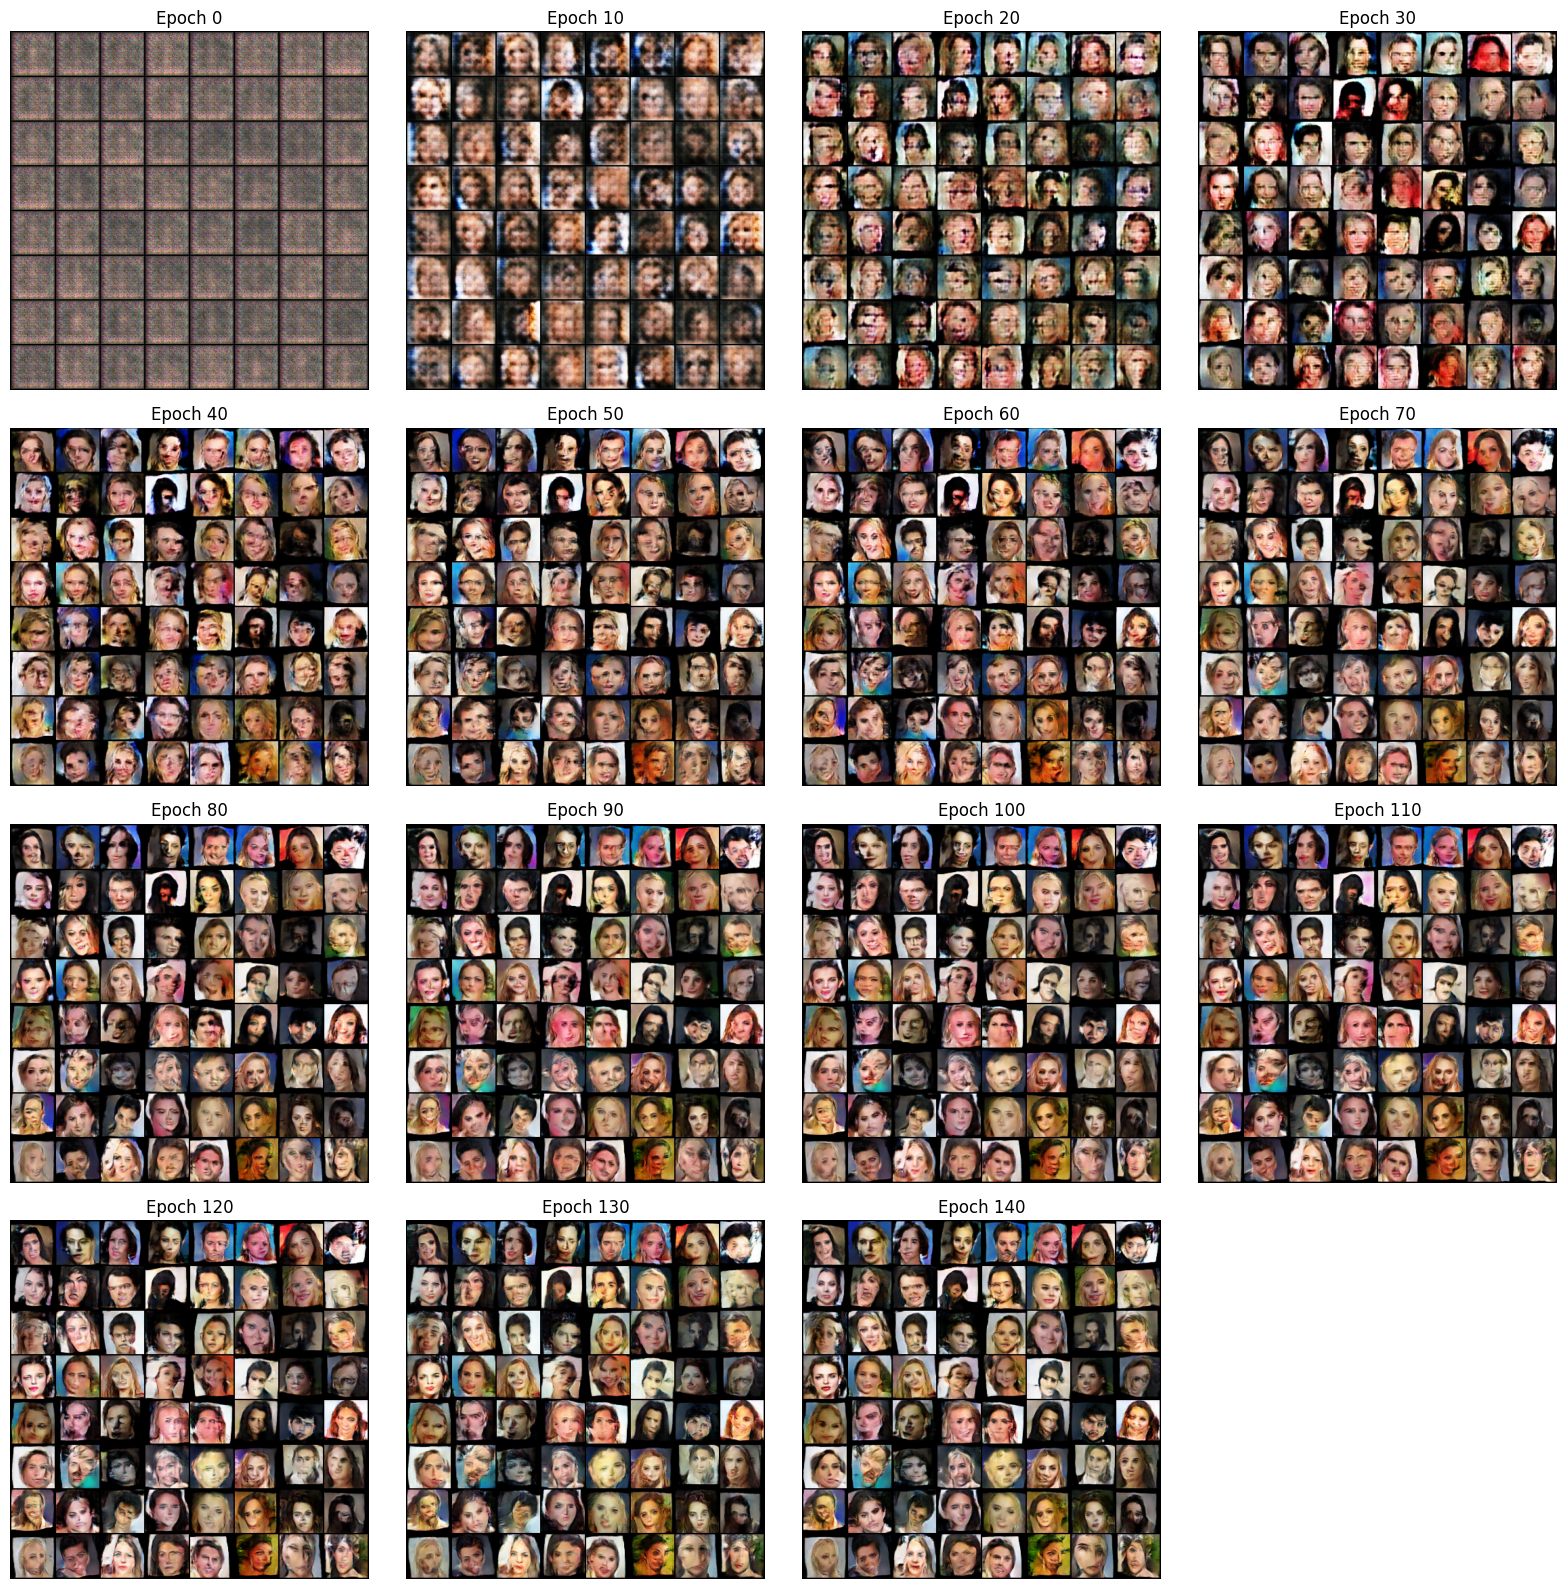

In [9]:
import os 
import matplotlib.pyplot as plt
from PIL import Image

folder_path = "/kaggle/working/dcgan_results"
epochs = list(range(0,151,10))

image_paths=[]
valid_epochs=[]

for epoch in epochs:
    filename=f"epoch_{epoch}.png"
    filepath=os.path.join(folder_path,filename)
    if os.path.exists(filepath):
        image_paths.append(filepath)
        valid_epochs.append(epoch)
    else:
        print(f"Worning: {filename} not found.")

n_image= len(image_paths)
cols=4 
rows = (n_image + cols - 1) // cols

plt.figure(figsize=(4*cols,rows*4))
for i, (epch,path) in enumerate(zip(valid_epochs,image_paths)):
    img= Image.open(path)
    plt.subplot(rows,cols,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Epoch {epch}',fontsize=12)
    
plt.tight_layout()
plt.show()

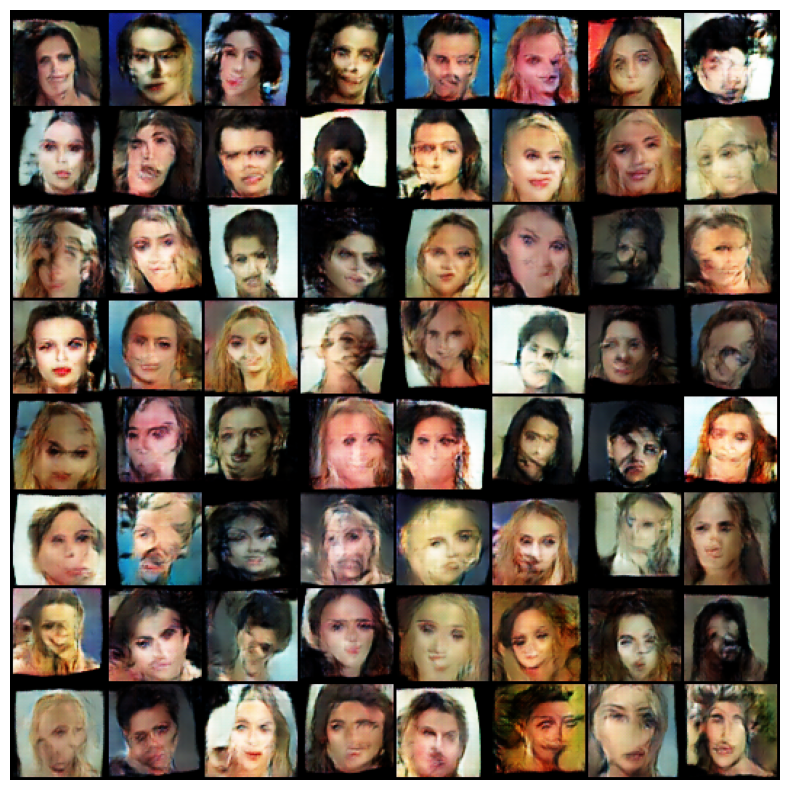

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and display the image
img = Image.open("/kaggle/working/dcgan_results/epoch_139.png")
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  
plt.show()

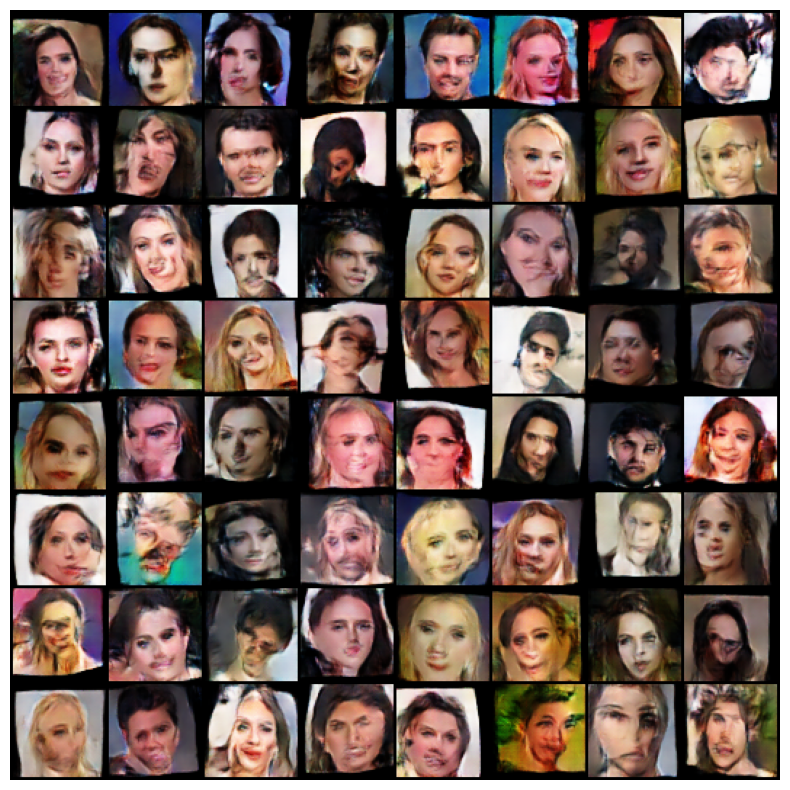

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and display the image
img = Image.open("/kaggle/working/dcgan_results/epoch_149.png")
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  
plt.show()